In [2]:
%run utilities_general.ipynb
%run utilities_DIRKs_and_PIRKs.ipynb 
load_standard_packages()
change_wordir()
import itertools as it
from tqdm import tqdm

C:\Users\andre\AppData\Local\Temp\ipykernel_41516\1467589274.py:1: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.1)
  from scipy import interpolate
Could not find cannot import name 'dopri5' from 'assimulo.lib' (c:\Users\andre\miniconda3\envs\python312\Lib\site-packages\assimulo\lib\__init__.py)
Could not find cannot import name 'rodas' from 'assimulo.lib' (c:\Users\andre\miniconda3\envs\python312\Lib\site-packages\assimulo\lib\__init__.py)
Could not find cannot import name 'odassl' from 'assimulo.lib' (c:\Users\andre\miniconda3\envs\python312\Lib\site-packages\assimulo\lib\__init__.py)
Could not find ODEPACK functions.
Could not find RADAR5
Could not find GLIMDA.


1.58.0


In [3]:
analysis = "DIRKs"

colors, colours = colourblind_palette("own")

#model = "saadat21"
#model = "ODE_v0"
#model = "ODE_v1"
#model = "new_PSI"
#model = "new_PSs"
#model = "new_b6f"
model = "with_dpsi"
#model = "latest_dev"

m = load_model(model)


succesfully loaded with_dpsi :D


In [4]:
# I like to have light as a derived variable
m.add_algebraic_module(module_name = "Light",
    function = lambda X, PFD: PFD, # X is not used
    compounds = ["PQ"], derived_compounds = ["L"], parameters = ['pfd'])

In [5]:
y0 = get_stst_y0(m)

# DIRK

In [15]:
pre_relax_time = 0.025
pfd_illum = 2000
relax_time = 0.04
relax_pfd = 0
post_relax_time = 0.1

protocol = [(pre_relax_time, pfd_illum),
            (relax_time, relax_pfd),
            (post_relax_time, pfd_illum)
            ]

In [16]:
s = Simulator(m)
s.initialise(y0)
s.update_parameters({"kATPsynth": 15})

c, v = apply_protocol(s, protocol, protocol_time_is_accumulated = False, use_tqdm = True, shift_time = True, input_in_ms= False, output_in_ms= True) 

100%|██████████| 3/3 [00:02<00:00,  1.04it/s]


In [17]:
# c = checkpoint("c", f"{model}/{analysis}", "c", overwrite=True) # to recover original code quickly once changed
# v = checkpoint("v", f"{model}/{analysis}", "v", overwrite=True)

# c = checkpoint("c", f"{model}/{analysis}", "c", overwrite=True) 
# v = checkpoint("v", f"{model}/{analysis}", "v", overwrite=True)

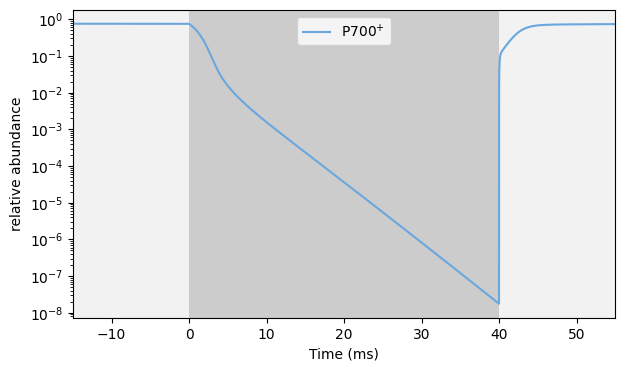

In [18]:
fig,ax1=plt.subplots(figsize=(7,4))
#ax 1
ax1.plot(c["rel_P700+"], label = "P700$^{+}$", color=colors[0])
#ax1.plot(c["rel_P700FA"], label = "P700FA", color=colors[1])
# ax1.plot(c["rel_P700+FA"], label = "P700$^{+}$FA", color=colors[2])

# ax2.plot(c["rel_P700+FA-"], label = "P700$^{+}$FA$^{-}$", color=colors[3]])
# if model != "cyclic_2021":
#        ax2.plot(c["rel_P700FA-"], label = "P700FA$^-$", color=colors[4])


ax1.set(#ylim=(0, 0.15),
       xlabel=("Time (ms)"),
       ylabel=("relative abundance"),
       xlim=(-15, 55),
       yscale = "log"
       )
shade_light(c, ax1)

ax1.legend(loc = "upper center")
       
plt.show()

In [19]:
save_fig(fig, model, analysis, "P700p")

existing figure backed up to figures/with_dpsi/DIRKs/Z_backup_P700p.png
saved figure to figures/with_dpsi/DIRKs/P700p.png


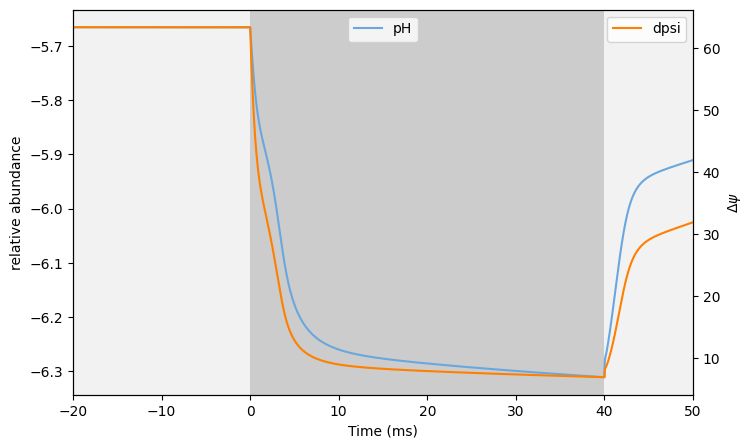

In [20]:
fig,ax1=plt.subplots(figsize=(8,5))
ax2 = ax1.twinx()

#ax 1
ax1.plot(-c["pH"], label = "pH", color=colors[0])
ax2.plot(c["dpsi"]*1e6, label = "dpsi", color=colors[1])

ax1.set(#ylim=(0, 0.15),
    xlabel=("Time (ms)"),
    ylabel=("relative abundance"),
    xlim=(-20,50))
shade_light(c, ax1)
ax1.legend(loc = "upper center")

ax2.set(ylabel = (r"$\Delta \psi$"))
ax2.legend(loc = "upper right")    

plt.show()

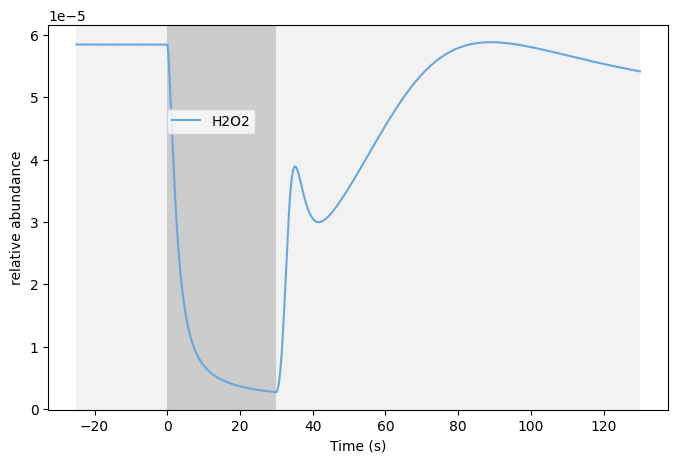

In [13]:
fig,ax1=plt.subplots(figsize=(8,5))

#ax 1
ax1.plot(c["H2O2"], label = "H2O2", color=colors[0])

ax1.set(#ylim=(0, 0.15),
    xlabel=("Time (s)"),
    ylabel=("relative abundance"))
shade_light(c, ax1)
ax1.legend(loc = "upper left")

ax1.legend(loc = "upper left", bbox_to_anchor=(0.18, 0.8))
    
plt.show()

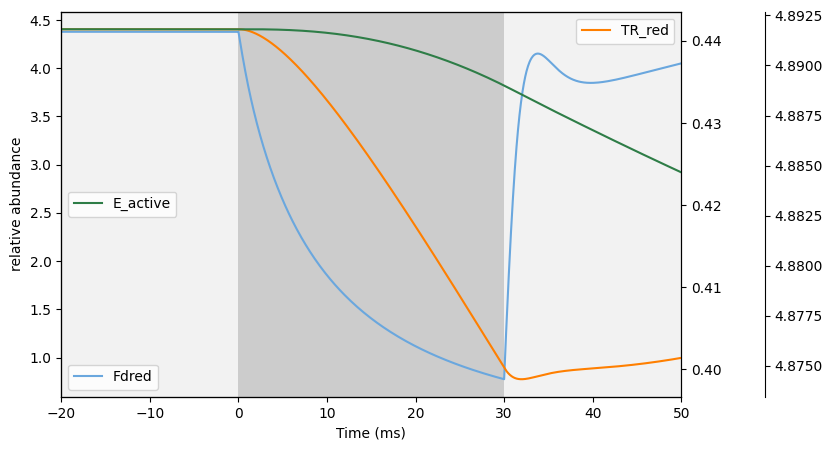

In [ ]:
fig,ax1=plt.subplots(figsize=(8,5))
ax2 = ax1.twinx()
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))  # Offset the third y-axis
# ax4 = ax1.twinx()
# ax4.spines['right'].set_position(('outward', 120))  # Offset the third y-axis

#ax 1
ax1.plot(c["Fdred"], label = "Fdred", color=colors[0])
ax2.plot(c["TR_red"], label = "TR_red", color=colors[1])
ax3.plot(c["E_active"], label = "E_active", color=colors[2])
# ax4.plot(c["E_inactive"], label = "E_inactive", color=colors[3])

ax1.set(#ylim=(0, 0.15),
    xlabel=("Time (ms)"),
    ylabel=("relative abundance"),
    xlim=(-20,50))
shade_light(c, ax1)
ax1.legend(loc = "lower left")

ax2.set(ylabel = (r""))
ax2.legend(loc = "upper right")

ax3.legend(loc = "center left")

plt.show()

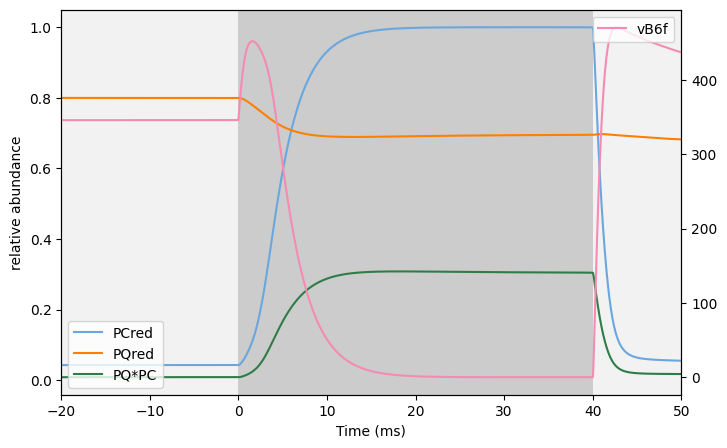

In [26]:
fig,ax1=plt.subplots(figsize=(8,5))
ax2 = ax1.twinx()

#ax 1
ax1.plot(c["PC_redoxstate"], label = "PCred", color=colors[0])
ax1.plot(c["PQ_redoxstate"], label = "PQred", color=colors[1])
ax1.plot(c["PC_redoxstate"]*(1-c["PQ_redoxstate"]), label = "PQ*PC", color=colors[2])
ax2.plot(v["vB6f"], label = "vB6f", color=colors[3])

ax1.set(#ylim=(0, 0.15),
    xlabel=("Time (ms)"),
    ylabel=("relative abundance"),
    xlim=(-20,50))
shade_light(c, ax1)
ax1.legend(loc = "lower left")

ax2.set(ylabel = (r""))
ax2.legend(loc = "upper right")

plt.show()